In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Style général
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)

print("✅ Imports OK")

✅ Imports OK


In [2]:
df = pd.read_csv("../data/support2.csv")

print("=" * 50)
print(f"📐 Dimensions     : {df.shape[0]} lignes × {df.shape[1]} colonnes")
print(f"💾 Taille mémoire : {df.memory_usage(deep=True).sum() / 1024:.1f} KB")
print("=" * 50)
df.head()

📐 Dimensions     : 9105 lignes × 48 colonnes
💾 Taille mémoire : 6826.8 KB


,id,age,death,sex,hospdead,slos,d.time,dzgroup,dzclass,num.co,...,crea,sod,ph,glucose,bun,urine,adlp,adls,sfdm2,adlsc
0,1,62.84998,0,male,0,5,2029,Lung Cancer,Cancer,0,...,1.199951,141.0,7.459961,NaN,NaN,NaN,7.0,7.0,NaN,7.0
1,2,60.33899,1,female,1,4,4,Cirrhosis,COPD/CHF/Cirrhosis,2,...,5.500000,132.0,7.250000,NaN,NaN,NaN,NaN,1.0,<2 mo. follow-up,1.0
2,3,52.74698,1,female,0,17,47,Cirrhosis,COPD/CHF/Cirrhosis,2,...,2.000000,134.0,7.459961,NaN,NaN,NaN,1.0,0.0,<2 mo. follow-up,0.0
3,4,42.38498,1,female,0,3,133,Lung Cancer,Cancer,2,...,0.799927,139.0,NaN,NaN,NaN,NaN,0.0,0.0,no(M2 and SIP pres),0.0
4,5,79.88495,0,female,0,16,2029,ARF/MOSF w/Sepsis,ARF/MOSF,1,...,0.799927,143.0,7.509766,NaN,NaN,NaN,NaN,2.0,no(M2 and SIP pres),2.0


In [ ]:
print("📋 TYPES DE COLONNES")
print("=" * 50)

numeriques   = df.select_dtypes(include=[np.number]).columns.tolist()
categoriques = df.select_dtypes(include=['object']).columns.tolist()

print(f"\n🔢 Numériques   ({len(numeriques)}) :")
print(numeriques)

print(f"\n🔤 Catégorielles ({len(categoriques)}) :")
print(categoriques)

❓ VALEURS MANQUANTES
Colonne  Manquants  Pourcentage
   adlp       5641        61.95
  urine       4862        53.40
glucose       4500        49.42
    bun       4352        47.80
totmcst       3475        38.17
    alb       3372        37.03
 income       2982        32.75
   adls       2867        31.49
   bili       2601        28.57
   pafi       2325        25.54
     ph       2284        25.09
  prg2m       1649        18.11
    edu       1634        17.95
  prg6m       1633        17.94
  sfdm2       1400        15.38
 totcst        888         9.75
   wblc        212         2.33
charges        172         1.89
avtisst         82         0.90
   crea         67         0.74
   race         42         0.46
 dnrday         30         0.33
    dnr         30         0.33
  scoma          1         0.01
    sps          1         0.01
 meanbp          1         0.01
    aps          1         0.01
 surv2m          1         0.01
 surv6m          1         0.01
   resp          1 

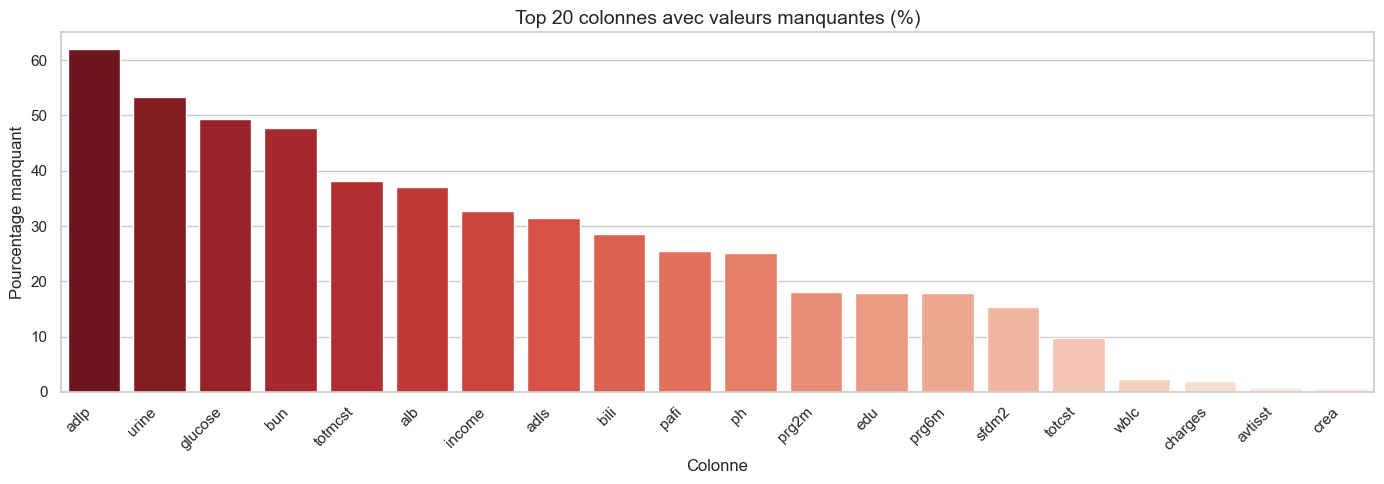

In [3]:
print("❓ VALEURS MANQUANTES")
print("=" * 50)

missing     = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Colonne'     : missing.index,
    'Manquants'   : missing.values,
    'Pourcentage' : missing_pct.values
}).query('Manquants > 0').sort_values('Pourcentage', ascending=False)

print(missing_df.to_string(index=False))
print(f"\n⚠️  {len(missing_df)} colonnes ont des valeurs manquantes")

# Visualisation
plt.figure(figsize=(14, 5))
top20 = missing_df.head(20)
sns.barplot(data=top20, x='Colonne', y='Pourcentage', palette='Reds_r')
plt.xticks(rotation=45, ha='right')
plt.title("Top 20 colonnes avec valeurs manquantes (%)", fontsize=14)
plt.ylabel("Pourcentage manquant")
plt.tight_layout()
plt.savefig("../data/missing_values.png", dpi=150)
plt.show()

In [13]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/support2.csv')
numeriques   = df.select_dtypes(include=[np.number]).columns.tolist()
categoriques = df.select_dtypes(include=['object']).columns.tolist()

print(f'✅ df chargé : {df.shape}')
print(f'✅ numeriques : {len(numeriques)} colonnes')

✅ df chargé : (9105, 48)
✅ numeriques : 40 colonnes


🎯 VARIABLE CIBLE : death
  0 = Survie  : 2904 patients (31.9%)
  1 = Décès   : 6201 patients (68.1%)


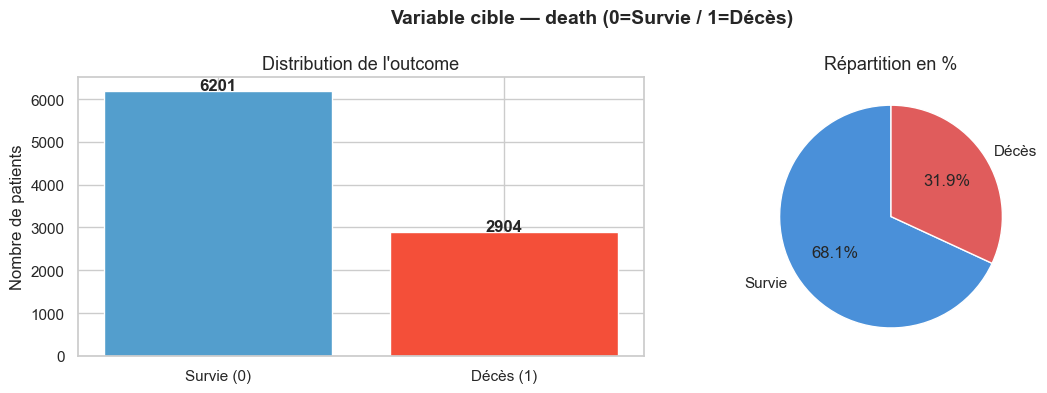

In [5]:
print("🎯 VARIABLE CIBLE : death")
print("=" * 50)

counts = df['death'].value_counts()
pcts   = df['death'].value_counts(normalize=True) * 100

print(f"  0 = Survie  : {counts[0]} patients ({pcts[0]:.1f}%)")
print(f"  1 = Décès   : {counts[1]} patients ({pcts[1]:.1f}%)")

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
axes[0].bar(['Survie (0)', 'Décès (1)'], counts.values,
            color=[sns.color_palette("Blues")[3], sns.color_palette("Reds")[3]])
axes[0].set_title("Distribution de l'outcome", fontsize=13)
axes[0].set_ylabel("Nombre de patients")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 20, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(pcts.values, labels=['Survie', 'Décès'],
            autopct='%1.1f%%', colors=['#4A90D9', '#E05C5C'],
            startangle=90)
axes[1].set_title("Répartition en %", fontsize=13)

plt.suptitle("Variable cible — death (0=Survie / 1=Décès)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("../data/target_distribution.png", dpi=150)
plt.show()

👤 DISTRIBUTION DE L'ÂGE
count    9105.00
mean       62.65
std        15.59
min        18.04
25%        52.80
50%        64.86
75%        74.00
max       101.85
Name: age, dtype: float64


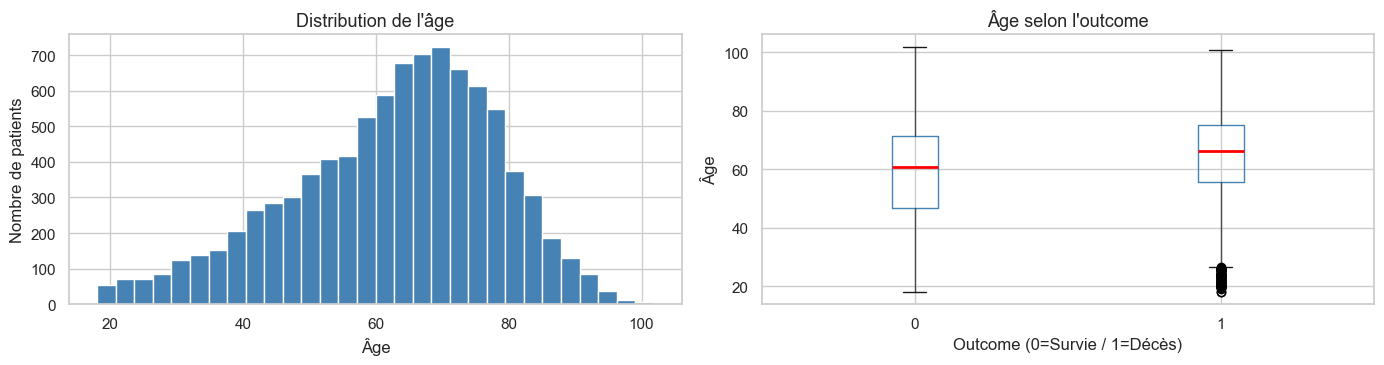

In [6]:
print("👤 DISTRIBUTION DE L'ÂGE")
print("=" * 50)
print(df['age'].describe().round(2))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histogram
axes[0].hist(df['age'].dropna(), bins=30, color='steelblue', edgecolor='white')
axes[0].set_title("Distribution de l'âge", fontsize=13)
axes[0].set_xlabel("Âge")
axes[0].set_ylabel("Nombre de patients")

# Boxplot par outcome
df.boxplot(column='age', by='death', ax=axes[1],
           boxprops=dict(color='steelblue'),
           medianprops=dict(color='red', linewidth=2))
axes[1].set_title("Âge selon l'outcome", fontsize=13)
axes[1].set_xlabel("Outcome (0=Survie / 1=Décès)")
axes[1].set_ylabel("Âge")
plt.suptitle("")

plt.tight_layout()
plt.savefig("../data/age_distribution.png", dpi=150)
plt.show()

✅ Features physiologiques disponibles : ['hrt', 'resp', 'temp', 'meanbp', 'wblc', 'pafi', 'crea', 'sod', 'ph', 'glucose']


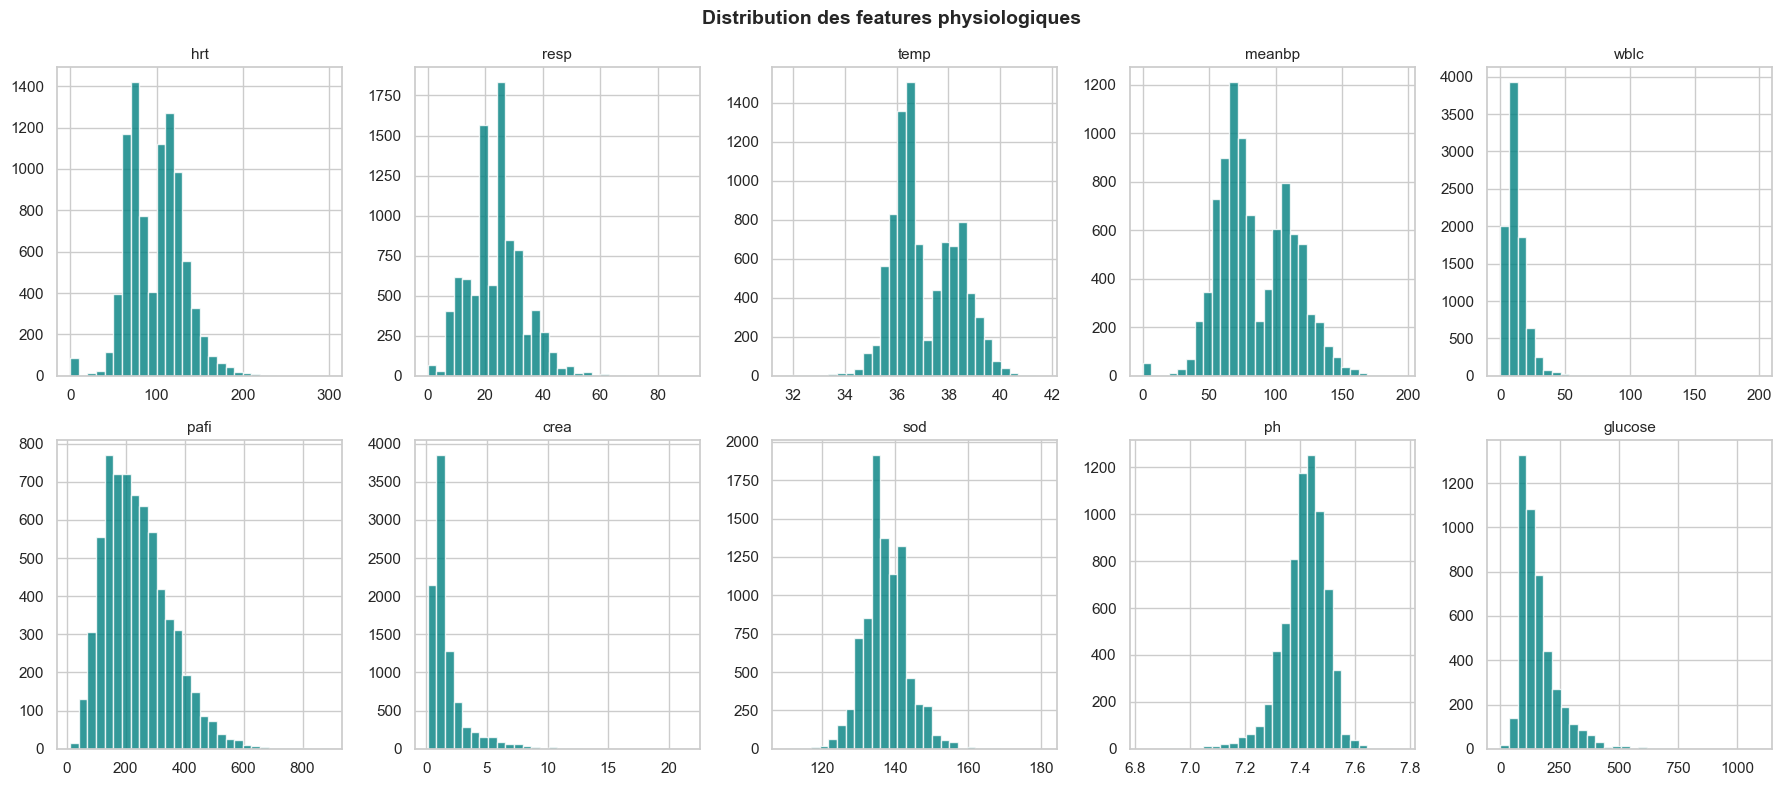

In [7]:
physio_cols = ['hrt', 'resp', 'temp', 'meanbp', 'wblc', 'pafi', 'crea', 'sod', 'ph', 'glucose']
physio_exist = [c for c in physio_cols if c in df.columns]

print(f"✅ Features physiologiques disponibles : {physio_exist}")

fig, axes = plt.subplots(2, 5, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(physio_exist):
    df[col].dropna().hist(ax=axes[i], bins=30,
                          color='teal', edgecolor='white', alpha=0.8)
    axes[i].set_title(col, fontsize=11)
    axes[i].set_xlabel("")

# Cacher les axes vides
for j in range(len(physio_exist), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Distribution des features physiologiques", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("../data/physio_features.png", dpi=150)
plt.show()

🔥 MATRICE DE CORRÉLATION


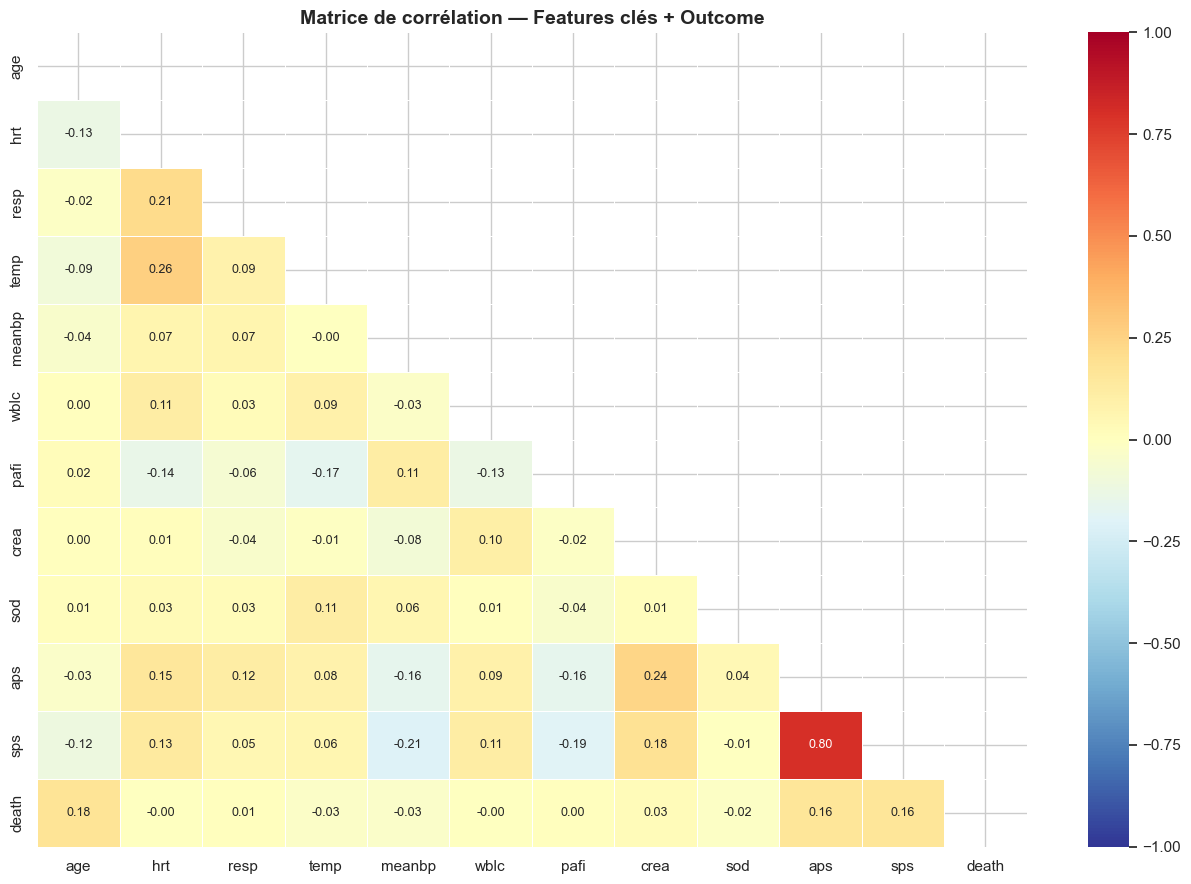

In [8]:
print("🔥 MATRICE DE CORRÉLATION")
print("=" * 50)

# Sélection colonnes numériques importantes
cols_corr = ['age', 'hrt', 'resp', 'temp', 'meanbp', 'wblc',
             'pafi', 'crea', 'sod', 'aps', 'sps', 'death']
cols_exist = [c for c in cols_corr if c in df.columns]

corr_matrix = df[cols_exist].corr()

plt.figure(figsize=(13, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlBu_r',
            mask=mask, vmin=-1, vmax=1,
            linewidths=0.5, annot_kws={"size": 9})
plt.title("Matrice de corrélation — Features clés + Outcome", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("../data/correlation_matrix.png", dpi=150)
plt.show()

🔍 DÉTECTION OUTLIERS


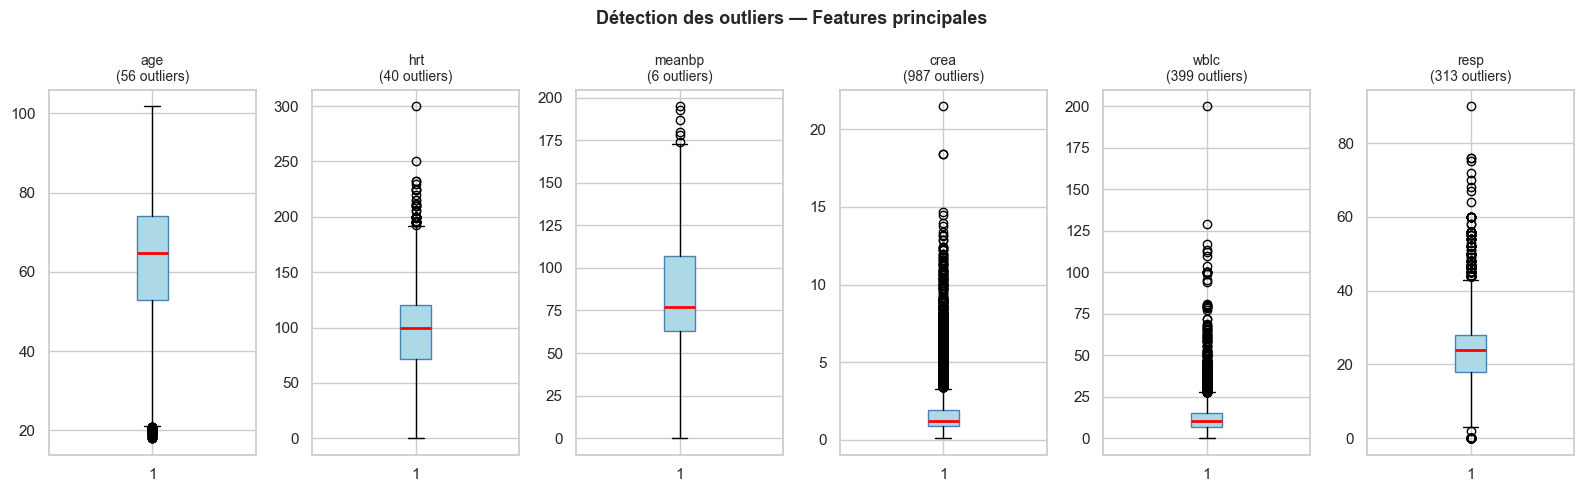

In [9]:
print("🔍 DÉTECTION OUTLIERS")
print("=" * 50)

outlier_cols = ['age', 'hrt', 'meanbp', 'crea', 'wblc', 'resp']
outlier_exist = [c for c in outlier_cols if c in df.columns]

fig, axes = plt.subplots(1, len(outlier_exist), figsize=(16, 5))

for i, col in enumerate(outlier_exist):
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)).sum()

    axes[i].boxplot(df[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='lightblue', color='steelblue'),
                    medianprops=dict(color='red', linewidth=2))
    axes[i].set_title(f"{col}\n({n_out} outliers)", fontsize=10)

plt.suptitle("Détection des outliers — Features principales", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("../data/outliers.png", dpi=150)
plt.show()

In [10]:
print("🗂️ SÉLECTION FINALE DES FEATURES PAR MODULE")
print("=" * 60)

features_ia_prediction = {
    'target'        : ['death'],
    'demographiques': ['age', 'sex', 'race'],
    'cliniques'     : ['dzgroup', 'num.co', 'scoma', 'dnr'],
    'physiologiques': ['hrt', 'resp', 'temp', 'meanbp', 'wblc', 'pafi', 'crea', 'sod'],
    'scores'        : ['aps', 'sps', 'surv2m', 'surv6m']
}

features_bi = {
    'kpis'       : ['death', 'hospdead', 'd.time', 'charges'],
    'groupement' : ['dzgroup', 'dzclass', 'age', 'sex', 'race']
}

# Vérifier disponibilité
print("\n📌 MODULE IA — Prédiction traitement :")
for cat, cols in features_ia_prediction.items():
    dispo = [c for c in cols if c in df.columns]
    print(f"   {cat:15s}: {dispo}")

print("\n📊 MODULE BI — Dashboard :")
for cat, cols in features_bi.items():
    dispo = [c for c in cols if c in df.columns]
    print(f"   {cat:15s}: {dispo}")

# Sauvegarde de la liste finale
all_features = []
for cols in features_ia_prediction.values():
    all_features.extend(cols)
for cols in features_bi.values():
    all_features.extend(cols)

final_features = list(set([c for c in all_features if c in df.columns]))
print(f"\n✅ Total features retenues : {len(final_features)}")
print(final_features)

🗂️ SÉLECTION FINALE DES FEATURES PAR MODULE

📌 MODULE IA — Prédiction traitement :
   target         : ['death']
   demographiques : ['age', 'sex', 'race']
   cliniques      : ['dzgroup', 'num.co', 'scoma', 'dnr']
   physiologiques : ['hrt', 'resp', 'temp', 'meanbp', 'wblc', 'pafi', 'crea', 'sod']
   scores         : ['aps', 'sps', 'surv2m', 'surv6m']

📊 MODULE BI — Dashboard :
   kpis           : ['death', 'hospdead', 'd.time', 'charges']
   groupement     : ['dzgroup', 'dzclass', 'age', 'sex', 'race']

✅ Total features retenues : 24
['aps', 'dzgroup', 'meanbp', 'scoma', 'resp', 'd.time', 'wblc', 'death', 'sod', 'race', 'sex', 'sps', 'dzclass', 'num.co', 'age', 'crea', 'pafi', 'dnr', 'charges', 'surv2m', 'temp', 'surv6m', 'hospdead', 'hrt']


In [11]:
# Garder seulement les colonnes utiles
df_clean = df[final_features].copy()

print(f"📐 Dataset original  : {df.shape}")
print(f"📐 Dataset sélectionné : {df_clean.shape}")
print(f"❓ Valeurs manquantes restantes : {df_clean.isnull().sum().sum()}")

# Sauvegarde
df_clean.to_csv("../data/support2_selected.csv", index=False)
print("\n✅ Dataset sauvegardé dans : data/support2_selected.csv")

📐 Dataset original  : (9105, 48)
📐 Dataset sélectionné : (9105, 24)
❓ Valeurs manquantes restantes : 2858

✅ Dataset sauvegardé dans : data/support2_selected.csv


In [12]:
# Dans ton terminal, lance cette commande :
print("🚀 Pour voir MLflow UI, ouvre un terminal et tape :")
print("\n   mlflow ui")
print("\n   Puis ouvre : http://localhost:5000")
print("\n   Tu verras ton run Semaine1_EDA avec tous les métriques et graphiques !")

🚀 Pour voir MLflow UI, ouvre un terminal et tape :

   mlflow ui

   Puis ouvre : http://localhost:5000

   Tu verras ton run Semaine1_EDA avec tous les métriques et graphiques !
